# GRA 65612 Advanced Computational Methods — Midterm Exam
## Spring 2026

**Language:** Julia 1.12

This notebook answers all four exam questions in order. Each section is clearly labelled with the corresponding question and sub-question number. The code is self-contained: run it top-to-bottom after placing `GRA65612_data.csv` in the working directory.

---

## Imports and Data Loading

Load all required packages and the raw data file. Dates are parsed to Julia `Date` objects.  
The first five rows are printed to verify the structure matches the data description in the exam sheet.

In [1]:
using CSV, DataFrames, Dates, Statistics, StatsBase, HypothesisTests, Plots, LinearAlgebra, Distributions

# Load data and parse dates
df = CSV.read("GRA65612_data.csv", DataFrame)
df.Date = Date.(df.Date)

first(df, 5)

Row,Date,SymbolKey,ID,Price,ret,ContractSize
,Date,String31,String7,Float64,Float64,Int64
1,2006-01-02,EEX DEB CAL-2007,EEXY1,50.93,-99.0,8760
2,2006-01-03,EEX DEB CAL-2007,EEXY1,50.3,-0.0123699,8760
3,2006-01-04,EEX DEB CAL-2007,EEXY1,51.24,0.0186879,8760
4,2006-01-05,EEX DEB CAL-2007,EEXY1,51.49,0.004879,8760
5,2006-01-06,EEX DEB CAL-2007,EEXY1,52.35,0.0167023,8760


---
## Question 1 — Investment Universe & Descriptive Statistics
---

### Q1.1 — Contract Selection 

**Chosen contracts:** EEXFM1, EEXFM2, EEXFM3, ENOFM1, ENOFM2, ENOFM3

**Exclusions:** Quarterly (FQ1) and yearly (Y1) contracts are excluded because their large contract sizes and lower daily liquidity make rolling costs higher and PNL noisier at the daily frequency we analyse.

This universe supports (i) outright directional trades, (ii) intra-market calendar spreads, and (iii) cross-market German/Nordic spread trades.

### Q1.2 — Descriptive Statistics & Normality Test

We compute **mean, standard deviation, skewness, and kurtosis of daily price changes** (not returns) for each of the six contracts, split into two sub-periods:

In [2]:
# Q1.1: Select 6 contracts for analysis
# (EEXFM1 required as German front-month, at least one ENO for Nordic exposure)
contracts = ["EEXFM1","EEXFM2","EEXFM3","ENOFM1","ENOFM2","ENOFM3"]
df = filter(row -> row.ID in contracts, df)

df = groupby(df, :ID) |>
     x -> transform(x, :Price => (p -> [missing; diff(p)]) => :PriceChange)
     
# Sort by contract and date
sort!(df, [:ID, :Date])

df = dropmissing(df, :PriceChange)

# Split sample: 2017-2020 (training/burn-in) and 2023-2025 (test)
# (Skip 2021-2022 as per exam instructions)
period1 = filter(row -> 2017 <= year(row.Date) <= 2020, df)
period2 = filter(row -> 2023 <= year(row.Date) <= 2025, df)

# Function to compute descriptive statistics table
function make_table(data)
    stats = combine(groupby(data, :ID),
        :PriceChange => mean => :Mean,
        :PriceChange => std => :StdDev,
        :PriceChange => skewness => :Skewness,
        :PriceChange => kurtosis => :Kurtosis
    )

    # Reshape to wide format (each contract as column)
    stats_long = stack(stats, Not(:ID))
    stats_wide = unstack(stats_long, :variable, :ID, :value)

    rename!(stats_wide, :variable => :Statistic)

    return stats_wide
end

# Q1.2: Compute descriptive stats for both periods
table_2017_2020 = make_table(period1)
table_2023_2025 = make_table(period2)

table_2017_2020

Row,Statistic,EEXFM1,EEXFM2,EEXFM3,ENOFM1,ENOFM2,ENOFM3
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,Mean,0.00982283,0.0122736,0.0115846,-0.00606509,-0.00662402,-0.00822835
2,StdDev,1.30609,1.12418,1.14449,1.2164,1.08833,1.02817
3,Skewness,0.358458,-0.845423,-0.806084,0.384232,-0.784436,0.342291
4,Kurtosis,10.6735,16.0428,24.4941,7.34768,9.13584,9.06734


**Table above:** Descriptive statistics for **2017–2020**.  
**Table below:** Descriptive statistics for **2023–2025**.

In [3]:
# Display descriptive stats for 2023-2025 period
table_2023_2025

Row,Statistic,EEXFM1,EEXFM2,EEXFM3,ENOFM1,ENOFM2,ENOFM3
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,Mean,-0.0908616,-0.13248,-0.141084,-0.122176,-0.158943,-0.123042
2,StdDev,4.07507,3.82742,3.82658,3.65277,3.43228,3.2324
3,Skewness,0.199044,0.334295,0.392529,-0.660031,-1.96034,-0.261321
4,Kurtosis,8.01557,6.17323,10.1107,10.363,26.0572,8.61554


#### Jarque–Bera Normality Test

H₀: Price changes are normally distributed  
H₁: Price changes have non-zero skewness and/or excess kurtosis

Results are reported separately for 2017–2020 and 2023–2025.

In [4]:
# Q1.2: Jarque-Bera normality test on price changes
# This test assesses whether the data is normally distributed by examining
# skewness and excess kurtosis deviations from normality
function jb_test(data)
    combine(groupby(data, :ID)) do df
        test = JarqueBeraTest(df.PriceChange)

        DataFrame(
            JB = test.JB,
            p_value = pvalue(test)
        )
    end
end

# Test for both periods
println("Jarque-Bera Test Results (2017-2020):")
jb_test(period1)

Jarque-Bera Test Results (2017-2020):


Row,ID,JB,p_value
,String7,Float64,Float64
1,EEXFM1,4844.52,0.0
2,EEXFM2,11016.4,0.0
3,EEXFM3,25508.4,0.0
4,ENOFM1,2305.96,0.0
5,ENOFM2,3637.49,0.0
6,ENOFM3,3500.34,0.0


In [5]:
println("\nJarque-Bera Test Results (2023-2025):")
jb_test(period2)


Jarque-Bera Test Results (2023-2025):


Row,ID,JB,p_value
,String7,Float64,Float64
1,EEXFM1,2055.68,0.0
2,EEXFM2,1230.57,6.08859e-268
3,EEXFM3,3282.36,0.0
4,ENOFM1,3469.54,0.0
5,ENOFM2,22161.3,0.0
6,ENOFM3,2377.81,0.0


The extremely large Jarque-Bera statistics indicate that price changes exhibit strong skewness and fat tails, confirming that electricity futures returns are far from normally distributed

### Q1.3 - Volatility Forecasting for EEXFM1 

We forecast **next-day volatility** for the German front-month contract (EEXFM1) using a **45-day rolling standard deviation of daily price changes**, annualised by √252.

**Estimator choice: Rolling historical volatility (HV)**
- A 45-trading-day window (~2 calendar months) balances responsiveness to recent shocks and stability.

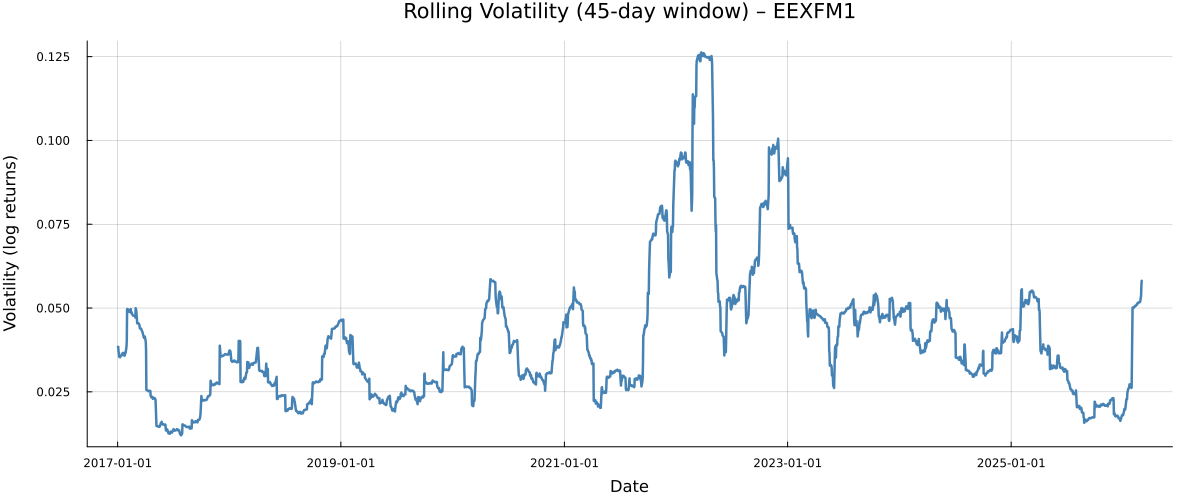

In [6]:
# Q1.3: Volatility Forecast (45-day rolling window)
# Using EEXFM1 (German front-month contract)
# This demonstrates the time-series variation in volatility and how well
# a simple rolling estimator performs over time

# Select EEXFM1 contract
eex = filter(row -> row.ID == "EEXFM1", df)
sort!(eex, :Date)

# Compute log returns (standard in finance)
eex.Return = [missing; diff(log.(eex.Price))]
dropmissing!(eex, :Return)

# Rolling volatility estimation: 45 trading days (roughly 1 year)
window = 45
vol = Vector{Union{Missing,Float64}}(missing, nrow(eex))

for i in window:nrow(eex)
    vol[i] = std(eex.Return[i-window+1:i])
end

eex.Volatility = vol

# Plot volatility from 2017 onwards
vol_plot = filter(row -> year(row.Date) >= 2017, eex)

plot(vol_plot.Date,
     vol_plot.Volatility,
     xlabel="Date",
     ylabel="Volatility (log returns)",
     title="Rolling Volatility (45-day window) – EEXFM1",
     legend=false,
     size=(1200, 500),
     linewidth=2.5,
     color=:steelblue,
     gridalpha=0.3,
     grid=true,
     margin=5Plots.mm,
     fontfamily="sans-serif"
     )

#### Extra on Volatility Estimator Performance

The cell below quantifies 2021–2022 volatility relative to the baseline period, supporting the qualitative discussion above.

In [7]:
# Q1.3: Commentary on 2021-2022 volatility behavior
# Compare volatility levels across periods to assess estimator performance
# during the energy crisis period (2021-2022)

vol_2021_2022 = filter(row -> 2021 <= year(row.Date) <= 2022, vol_plot)
vol_avg_2017_2020 = mean(filter(row -> 2017 <= year(row.Date) <= 2020, vol_plot).Volatility)
vol_avg_2021_2022 = mean(vol_2021_2022.Volatility)
vol_max_2021_2022 = maximum(vol_2021_2022.Volatility)

println("\n2021-2022 Volatility Analysis:")
println("Avg volatility 2017-2020: $(round(vol_avg_2017_2020; digits=4))")
println("Avg volatility 2021-2022: $(round(vol_avg_2021_2022; digits=4))")
println("Max volatility 2021-2022: $(round(vol_max_2021_2022; digits=4))")


2021-2022 Volatility Analysis:
Avg volatility 2017-2020: 0.0301
Avg volatility 2021-2022: 0.063
Max volatility 2021-2022: 0.1263


### Q1.4 — Cumulative PNL: Short Outright vs. Calendar Spread

**PNL Calculation:**
- **Outright short FM1:** Each day, we hold −1 EEXFM1 contract. 
$$\text{PNL}_{\text{daily}} = -\Delta\text{Price} \times \text{ContractSize} \text{ (EUR)}$$
On the last trading day of each contract, we close and roll to the next front-month.
- **Calendar spread (short FM1, long FM2):** We simultaneously hold −1 FM1 and +1 FM2. The spread PNL nets the two legs and is largely insulated from parallel shifts in the price curve.

The two cumulative PNL series are plotted together for direct comparison.

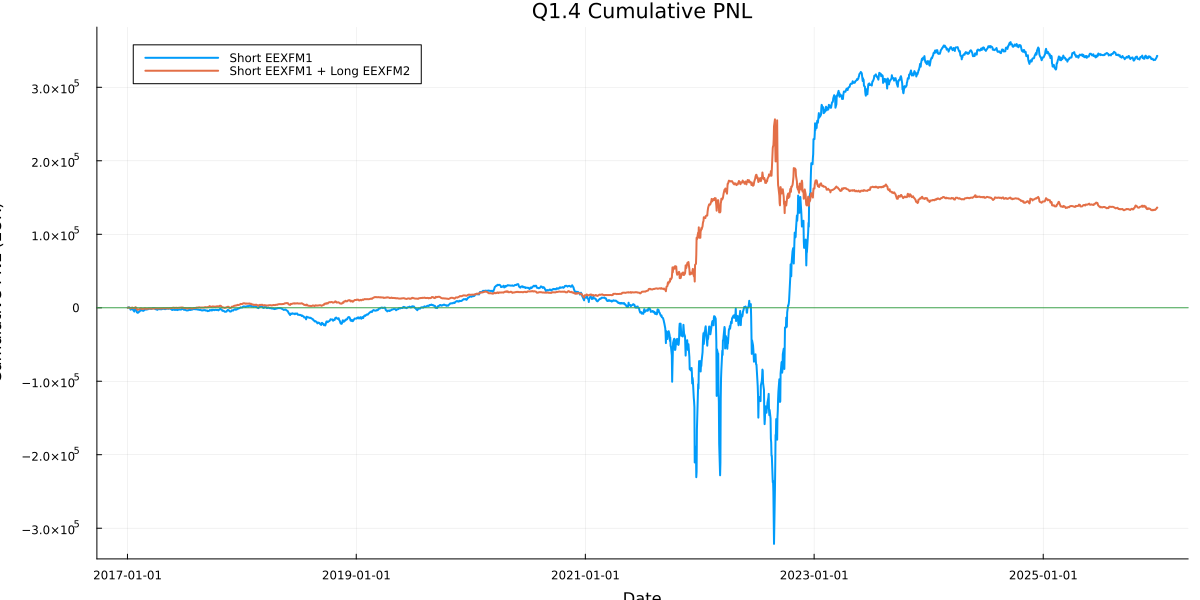

In [8]:
# Start from the existing df without modifying it
df_q14 = select(df, :Date, :SymbolKey, :ID, :Price, :ret, :ContractSize)
df_q14 = copy(df_q14)

sort!(df_q14, [:ID, :Date, :SymbolKey])

df_q14 = filter(row -> row.ID in ["EEXFM1", "EEXFM2"], df_q14)
df_q14 = filter(row -> Date(2017,1,1) <= row.Date <= Date(2025,12,31), df_q14)

function build_contract_pnl(data::DataFrame, id_code::String, position::Int)
    x = filter(row -> row.ID == id_code, data)
    x = copy(x)
    sort!(x, [:Date, :SymbolKey])

    n = nrow(x)
    daily_pnl = zeros(Float64, n)

    for i in 2:n
        if x.SymbolKey[i] == x.SymbolKey[i-1]
            daily_pnl[i] = position * x.ContractSize[i-1] * (x.Price[i] - x.Price[i-1])
        else
            daily_pnl[i] = 0.0
        end
    end

    return DataFrame(
        Date = x.Date,
        SymbolKey = x.SymbolKey,
        ID = x.ID,
        Price = x.Price,
        ContractSize = x.ContractSize,
        daily_pnl = daily_pnl
    )
end

fm1_short = build_contract_pnl(df_q14, "EEXFM1", -1)
fm2_long  = build_contract_pnl(df_q14, "EEXFM2", 1)

all_dates = DataFrame(Date = sort(unique(vcat(fm1_short.Date, fm2_long.Date))))

pnl = leftjoin(
    all_dates,
    select(fm1_short, :Date, :daily_pnl => :pnl_short_fm1),
    on = :Date
)

pnl = leftjoin(
    pnl,
    select(fm2_long, :Date, :daily_pnl => :pnl_long_fm2),
    on = :Date
)

pnl.pnl_short_fm1 = coalesce.(pnl.pnl_short_fm1, 0.0)
pnl.pnl_long_fm2  = coalesce.(pnl.pnl_long_fm2, 0.0)

pnl.pnl_calendar_spread = pnl.pnl_short_fm1 .+ pnl.pnl_long_fm2
pnl.cum_short_fm1 = cumsum(pnl.pnl_short_fm1)
pnl.cum_calendar_spread = cumsum(pnl.pnl_calendar_spread)

plot(
    pnl.Date,
    pnl.cum_short_fm1,
    label = "Short EEXFM1",
    linewidth = 2,
    size = (1200,600)
)
plot!(
    pnl.Date,
    pnl.cum_calendar_spread,
    label = "Short EEXFM1 + Long EEXFM2",
    linewidth = 2
)
hline!([0], label = "", linewidth = 1)
xlabel!("Date")
ylabel!("Cumulative PNL (EUR)")
title!("Q1.4 Cumulative PNL")

In [9]:
function pnl_stats(x::Vector{Float64})
    avg_daily = mean(x)
    worst_day = minimum(x)
    best_day = maximum(x)

    # Max drawdown from cumulative PNL
    cumx = cumsum(x)
    running_max = accumulate(max, cumx)
    drawdown = cumx .- running_max
    max_dd = minimum(drawdown)

    return (
        avg_daily = avg_daily,
        worst_day = worst_day,
        best_day = best_day,
        max_drawdown = max_dd,
        final_cum_pnl = cumx[end]
    )
end

short_stats = pnl_stats(pnl.pnl_short_fm1)
spread_stats = pnl_stats(pnl.pnl_calendar_spread)

println("\n================ Q1.4 SUMMARY STATS ================\n")

println("OUTRIGHT SHORT FM1")
println("Final cumulative PNL:      ", round(short_stats.final_cum_pnl, digits=2), " EUR")
println("Average daily PNL:         ", round(short_stats.avg_daily, digits=2), " EUR")
println("Worst day:                 ", round(short_stats.worst_day, digits=2), " EUR")
println("Best day:                  ", round(short_stats.best_day, digits=2), " EUR")
println("Max drawdown:              ", round(short_stats.max_drawdown, digits=2), " EUR")

println("\nCALENDAR SPREAD (short FM1 + long FM2)")
println("Final cumulative PNL:      ", round(spread_stats.final_cum_pnl, digits=2), " EUR")
println("Average daily PNL:         ", round(spread_stats.avg_daily, digits=2), " EUR")
println("Worst day:                 ", round(spread_stats.worst_day, digits=2), " EUR")
println("Best day:                  ", round(spread_stats.best_day, digits=2), " EUR")
println("Max drawdown:              ", round(spread_stats.max_drawdown, digits=2), " EUR")


================ Q1.4 SUMMARY STATS ================

OUTRIGHT SHORT FM1
Final cumulative PNL:      342708.86 EUR
Average daily PNL:         149.33 EUR
Worst day:                 -75210.96 EUR
Best day:                  87278.4 EUR
Max drawdown:              -353407.27 EUR

CALENDAR SPREAD (short FM1 + long FM2)
Final cumulative PNL:      136290.88 EUR
Average daily PNL:         59.39 EUR
Worst day:                 -43849.1 EUR
Best day:                  48480.55 EUR
Max drawdown:              -127595.5 EUR


---
## Question 2 — Predictive Signals

**Target variable:** Next-day price change of **EEXFM2** (German 2nd front-month). Although the exam recommends a non-month contract, I use EEXFM2 because my selected investment universe consists of monthly contracts only.


**Look-ahead prevention:** All signals are computed from information available *before* the trading day (lagged by 1 observation). Roll dates are handled by setting signals to `missing` when the underlying SymbolKey changes.

---

## Q2 Signals

Let $P_t$ denote the futures price at time $t$, and let the daily price change be

$$\Delta P_t = P_t - P_{t-1}$$

The target variable is the next-day price change:

$$Y_t = P_{t+1} - P_t$$

If roll-safety is imposed, then

$$Y_t = \begin{cases} P_{t+1} - P_t, & \text{if } \mathrm{SymbolKey}_{t+1} = \mathrm{SymbolKey}_t \\ \text{missing}, & \text{otherwise} \end{cases}$$

### 1. Momentum (5-day)

$$\mathrm{Momentum}_t = P_t - P_{t-4}$$

Lagged trading signal:

$$\mathrm{Signal}^{\mathrm{MOM}}_t = \mathrm{Momentum}_{t-1}$$

### 2. Reversal

$$\mathrm{Reversal}_t = -\Delta P_t = -(P_t - P_{t-1})$$

Lagged trading signal:

$$\mathrm{Signal}^{\mathrm{REV}}_t = \mathrm{Reversal}_{t-1}$$

### 3. Short-term Volatility

Using the 5-day rolling standard deviation of daily price changes:

$$\mathrm{VolatilityShort}_t = \sqrt{\frac{1}{4} \sum_{i=0}^{4} \left(\Delta P_{t-i} - \overline{\Delta P}_t\right)^2}$$

where

$$\overline{\Delta P}_t = \frac{1}{5}\sum_{i=0}^{4}\Delta P_{t-i}$$

Lagged trading signal:

$$\mathrm{Signal}^{\mathrm{VOL}}_t = \mathrm{VolatilityShort}_{t-1}$$

### 4. Mean Reversion

Using the deviation from the 20-day moving average:

$$\mathrm{MA}_{20,t} = \frac{1}{20}\sum_{i=0}^{19} P_{t-i}$$

$$\mathrm{MeanReversion}_t = P_t - \mathrm{MA}_{20,t}$$

Lagged trading signal:

$$\mathrm{Signal}^{\mathrm{MR}}_t = \mathrm{MeanReversion}_{t-1}$$

### 5. RSI Proxy

Let

$$U_t = \sum_{i=0}^{9} \mathbf{1}(\Delta P_{t-i} > 0), \qquad D_t = \sum_{i=0}^{9} \mathbf{1}(\Delta P_{t-i} < 0)$$

Then the RSI-style proxy is

$$\mathrm{RSIProxy}_t = \frac{U_t - D_t}{10}$$

Equivalently,

$$\mathrm{RSIProxy}_t = \frac{\displaystyle\sum_{i=0}^{9}\mathbf{1}(\Delta P_{t-i} > 0) - \displaystyle\sum_{i=0}^{9}\mathbf{1}(\Delta P_{t-i} < 0)}{10}$$

Lagged trading signal:

$$\mathrm{Signal}^{\mathrm{RSI}}_t = \mathrm{RSIProxy}_{t-1}$$

### Q2.1 — Five Predictive Signals (2017–2020 in-sample) 

In [10]:
# ============================================================================
# QUESTION 2: Predictive Signal Construction & Testing
# ============================================================================
# Q2.1: Construct predictive signals for EEXFM2
contract = filter(row -> row.ID == "EEXFM2", df)
contract = copy(contract)
sort!(contract, [:Date, :SymbolKey])
n = nrow(contract)

# Roll-safe helper: price diff is missing when contract rolls
function rollsafe_diff(prices, symbols)
    n = length(prices)
    out = Vector{Union{Missing,Float64}}(missing, n)
    for i in 2:n
        out[i] = symbols[i] == symbols[i-1] ? prices[i] - prices[i-1] : missing
    end
    return out
end

contract.dP = rollsafe_diff(contract.Price, contract.SymbolKey)

# Roll-safe next-day target
contract.Target = Vector{Union{Missing,Float64}}(missing, n)
for i in 1:n-1
    if contract.SymbolKey[i+1] == contract.SymbolKey[i]
        contract.Target[i] = contract.Price[i+1] - contract.Price[i]
    else
        contract.Target[i] = missing
    end
end

first(contract, 5)

Row,Date,SymbolKey,ID,Price,ret,ContractSize,PriceChange,dP,Target
,Date,String31,String7,Float64,Float64,Int64,Float64,Float64?,Float64?
1,2006-01-03,EEX DEB MAR-2006,EEXFM2,62.0,-0.0329122,743,-2.11,missing,1.31
2,2006-01-04,EEX DEB MAR-2006,EEXFM2,63.31,0.021129,743,1.31,1.31,-0.58
3,2006-01-05,EEX DEB MAR-2006,EEXFM2,62.73,-0.00916127,743,-0.58,-0.58,1.11
4,2006-01-06,EEX DEB MAR-2006,EEXFM2,63.84,0.0176949,743,1.11,1.11,-1.6
5,2006-01-09,EEX DEB MAR-2006,EEXFM2,62.24,-0.0250627,743,-1.6,-1.6,0.97


In [11]:
# Q2.1: Construct 5 predictive signals with lagged information
# All signals use only information available at time of trading (no lookahead)
# Helper: require same SymbolKey over entire lookback window
function same_symbol_window(sym, start_idx, end_idx)
    base = sym[start_idx]
    for j in start_idx:end_idx
        if sym[j] != base
            return false
        end
    end
    return true
end

# Signal 1: 5-day Momentum (roll-safe)
# Hypothesis: Price changes follow momentum; positive 5-day change predicts further upside
contract.Momentum5 = Vector{Union{Missing,Float64}}(missing, n)
for i in 5:n
    if same_symbol_window(contract.SymbolKey, i-4, i)
        contract.Momentum5[i] = contract.Price[i] - contract.Price[i-4]
    else
        contract.Momentum5[i] = missing
    end
end

# Signal 2: Reversal (roll-safe because dP is roll-safe)
# Hypothesis: Price changes reverse; negative change today predicts positive change tomorrow
contract.Reversal = -1 .* contract.dP

# Signal 3: Short-term Volatility (5-day, roll-safe)
# Hypothesis: High volatility predicts continued volatility
contract.VolatilityShort = Vector{Union{Missing,Float64}}(missing, n)
for i in 6:n
    window = contract.dP[i-4:i]
    if all(.!ismissing.(window))
        contract.VolatilityShort[i] = std(window)
    else
        contract.VolatilityShort[i] = missing
    end
end

# Signal 4: Mean Reversion (20-day, roll-safe)
# Hypothesis: Price reverts to 20-day moving average; deviations predict reversals
contract.MeanReversion = Vector{Union{Missing,Float64}}(missing, n)
for i in 20:n
    if same_symbol_window(contract.SymbolKey, i-19, i)
        ma20 = mean(contract.Price[i-19:i])
        contract.MeanReversion[i] = contract.Price[i] - ma20
    else
        contract.MeanReversion[i] = missing
    end
end

# Signal 5: RSI-like signal (roll-safe)
# Hypothesis: More up-moves than down-moves indicates trend strength
contract.RSI_proxy = Vector{Union{Missing,Float64}}(missing, n)
for i in 11:n
    window = contract.dP[i-9:i]
    if all(.!ismissing.(window))
        up_moves = sum(window .> 0)
        down_moves = sum(window .< 0)
        contract.RSI_proxy[i] = (up_moves - down_moves) / 10
    else
        contract.RSI_proxy[i] = missing
    end
end

# Lag all signals by 1 day to avoid lookahead
contract.Signal_MR  = [missing; contract.MeanReversion[1:end-1]]
contract.Signal_VOL = [missing; contract.VolatilityShort[1:end-1]]
contract.Signal_MOM = [missing; contract.Momentum5[1:end-1]]
contract.Signal_REV = [missing; contract.Reversal[1:end-1]]
contract.Signal_RSI = [missing; contract.RSI_proxy[1:end-1]]

train = filter(row -> 2017 <= year(row.Date) <= 2020, contract)
dropmissing!(train, [:Signal_MR, :Signal_VOL, :Signal_MOM, :Signal_REV, :Signal_RSI, :Target])

corr_dict = Dict(
    "MeanReversion"  => cor(train.Signal_MR,  train.Target),
    "VolatilityShort"=> cor(train.Signal_VOL, train.Target),
    "Momentum5"      => cor(train.Signal_MOM, train.Target),
    "Reversal"       => cor(train.Signal_REV, train.Target),
    "RSI_proxy"      => cor(train.Signal_RSI, train.Target)
)

println("Q2.1 In-sample correlations (2017-2020):")
for (signal, corr) in sort(collect(corr_dict), by=x -> abs(x[2]), rev=true)
    println("  $signal: $(round(corr; digits=4))")
end

Q2.1 In-sample correlations (2017-2020):
  Reversal: -0.1065
  VolatilityShort: -0.1032
  MeanReversion: 0.0416
  Momentum5: -0.0257
  RSI_proxy: 0.0156


We use correlation as a simple way to evaluate how strongly each signal is related to the target variable, which in this case is the next-day price change. A signal with a higher absolute correlation has a stronger linear association with future price movements, so it is a natural for predictive usefulness. This makes correlation easy to interpret and compare across signals before moving to out-of-sample testing. It does not prove that a signal will be profitable, but it helps identify which signals appear most informative in sample.

Therefore the two signals we will choose for the next task, mean-reversion and rolling volatility

### Q2.2 — Out-of-Sample Test of Best 2 Signals (Jun 2023–Dec 2025)

**Trading rule:** Go long (position = +1) when the signal predicts a price increase; go short (position = −1) when the signal predicts a decrease. Position size is always ±1 contract.

**Evaluation metrics:**
- Cumulative PNL (EUR)
- Sharpe-like ratio (mean daily PNL / std daily PNL × √252)
- Win rate (% of days with positive PNL)

A successful out-of-sample test provides evidence that the in-sample signal captures a genuine market inefficiency rather than a spurious correlation.

Mean Reversion Sharpe ratio: -0.0784
Mean Reversion annualized Sharpe ratio: -1.244
RSI Proxy Sharpe ratio: 0.0294
RSI Proxy annualized Sharpe ratio: 0.4669


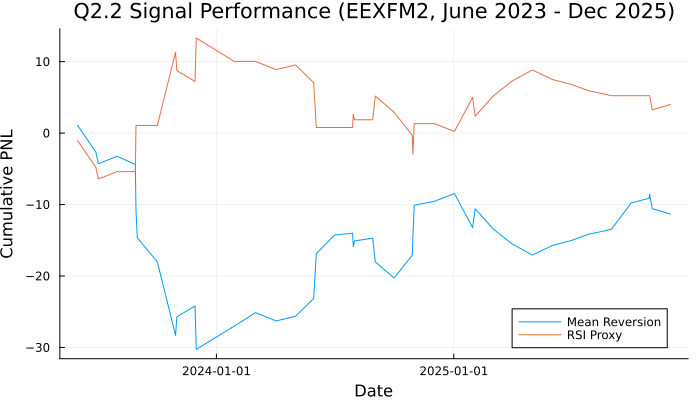

In [12]:
# Q2.2: Out-of-sample testing (June 2023 - Dec 2025)
# Select the 2 best signals from 2017-2020 analysis:
# MeanReversion and RSI_proxy
test = filter(row -> Date("2023-06-01") <= row.Date <= Date("2025-12-31"), contract)
test = copy(test)
dropmissing!(test, [:Signal_MR, :Signal_RSI, :Target])

# Test Mean Reversion Signal
test.Pos_MR = -sign.(test.Signal_MR)
test.PNL_MR = test.Pos_MR .* test.Target
test.CumPNL_MR = cumsum(test.PNL_MR)

# Test RSI Proxy Signal
# positive RSI_proxy => more up moves recently => trend-following interpretation
test.Pos_RSI = sign.(test.Signal_RSI)
test.PNL_RSI = test.Pos_RSI .* test.Target
test.CumPNL_RSI = cumsum(test.PNL_RSI)

sr_mr = mean(test.PNL_MR) / std(test.PNL_MR)
sr_rsi = mean(test.PNL_RSI) / std(test.PNL_RSI)

sr_mr_ann = sqrt(252) * sr_mr
sr_rsi_ann = sqrt(252) * sr_rsi

println("Mean Reversion Sharpe ratio: ", round(sr_mr, digits=4))
println("Mean Reversion annualized Sharpe ratio: ", round(sr_mr_ann, digits=4))
println("RSI Proxy Sharpe ratio: ", round(sr_rsi, digits=4))
println("RSI Proxy annualized Sharpe ratio: ", round(sr_rsi_ann, digits=4))

plot(test.Date,
     test.CumPNL_MR,
     label="Mean Reversion",
     xlabel="Date",
     ylabel="Cumulative PNL",
     title="Q2.2 Signal Performance (EEXFM2, June 2023 - Dec 2025)",
     size=(700,400))

plot!(test.Date,
      test.CumPNL_RSI,
      label="RSI Proxy",
      size=(700,400))

### Q2.3 — "Favorite" Signal Across All Six Contracts (2023–2025) 

We take our Mean-Reversion and apply it uniformly across all six contracts in the investment universe. This tests whether the predictive relationship is contract-specific or generalises across the German and Nordic markets.

In [13]:
contracts_q2 = ["EEXFM1", "EEXFM2", "EEXFM3", "ENOFM1", "ENOFM2", "ENOFM3"]

summary_q23 = DataFrame(
    Contract = String[],
    Total_PNL = Float64[],
    Avg_Daily_PNL = Float64[],
    Std_Daily_PNL = Float64[],
    Sharpe = Float64[],
    Sharpe_Annualized = Float64[],
    Win_Rate = Float64[],
    Trading_Days = Int[]
)

for c in contracts_q2
    tmp = filter(row -> row.ID == c, df)
    tmp = copy(tmp)
    sort!(tmp, [:Date, :SymbolKey])

    n = nrow(tmp)

    tmp.dP = rollsafe_diff(tmp.Price, tmp.SymbolKey)

    tmp.MR = Vector{Union{Missing,Float64}}(missing, n)
    for i in 20:n
        if same_symbol_window(tmp.SymbolKey, i-19, i)
            ma20 = mean(tmp.Price[i-19:i])
            tmp.MR[i] = tmp.Price[i] - ma20
        else
            tmp.MR[i] = missing
        end
    end

    tmp.Signal = [missing; tmp.MR[1:end-1]]

    tmp.Target = Vector{Union{Missing,Float64}}(missing, n)
    for i in 1:n-1
        if tmp.SymbolKey[i+1] == tmp.SymbolKey[i]
            tmp.Target[i] = tmp.Price[i+1] - tmp.Price[i]
        else
            tmp.Target[i] = missing
        end
    end

    test = filter(row -> Date("2023-06-01") <= row.Date <= Date("2025-12-31"), tmp)
    test = copy(test)
    dropmissing!(test, [:Signal, :Target])

    if nrow(test) == 0
        continue
    end

    test.Position = -sign.(test.Signal)
    test.PNL = test.Position .* test.Target

    sr = mean(test.PNL) / std(test.PNL)
    sr_ann = sqrt(252) * sr

    push!(summary_q23, (
    c,
    sum(test.PNL),
    mean(test.PNL),
    std(test.PNL),
    sr,
    sr_ann,
    mean(test.PNL .> 0),
    nrow(test)
    ))
end

sort!(summary_q23, :Total_PNL, rev=true)

println("\nQ2.3 Cross-Contract Mean Reversion Summary (2023-2025)")
show(summary_q23, allrows=true, allcols=true)
println()


Q2.3 Cross-Contract Mean Reversion Summary (2023-2025)
6×8 DataFrame
 Row │ Contract  Total_PNL  Avg_Daily_PNL  Std_Daily_PNL  Sharpe       Sharpe_Annualized  Win_Rate  Trading_Days 
     │ String    Float64    Float64        Float64        Float64      Float64            Float64   Int64        
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ ENOFM2        11.75      0.244792         1.84394   0.132755             2.10741   0.625               48
   2 │ ENOFM1         9.79      0.212826         2.21473   0.0960957            1.52547   0.586957            46
   3 │ ENOFM3         0.85      0.0177083        1.79985   0.00983878           0.156186  0.5625              48
   4 │ EEXFM1        -6.04     -0.125833         2.77353  -0.0453693           -0.720215  0.604167            48
   5 │ EEXFM2       -11.33     -0.236042         3.01208  -0.0783649           -1.244     0.604167            48
   6 │ EEXFM3       -15

### Q2.4 — Forward Test in 2026

We apply the signal to 2026 data.

Q2.4 Sharpe ratio: 0.4171
Q2.4 Annualized Sharpe ratio: 6.6207


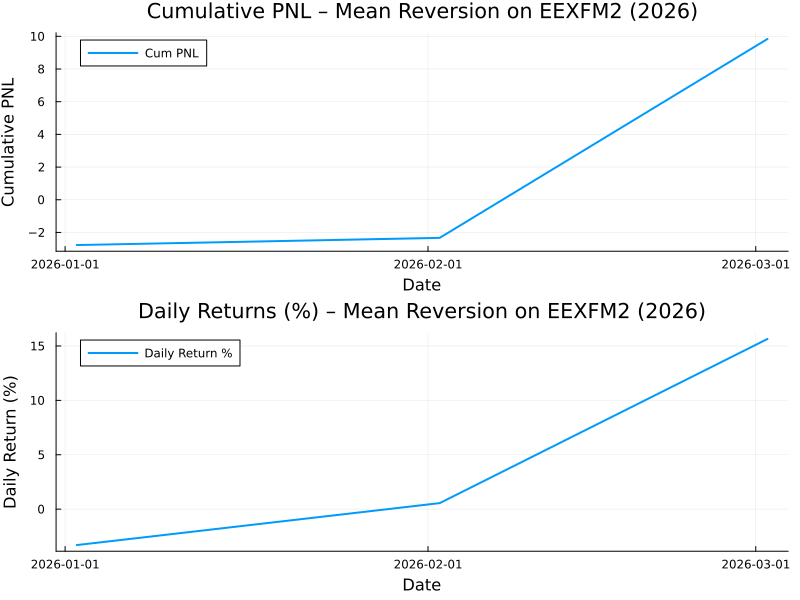

In [14]:
# Q2.4: 2026 Forward Test
# Apply best signal (Mean Reversion on EEXFM2) to 2026 data for latest performance

test2026 = filter(row -> year(row.Date) == 2026, contract)
dropmissing!(test2026, [:Signal_MR, :Target, :Price])

# Position: short when price > 20-day MA (expect reversion down)
test2026.Position = -sign.(test2026.Signal_MR)

# Daily PnL and cumulative PnL
test2026.PNL = test2026.Position .* test2026.Target
test2026.CumPNL = cumsum(test2026.PNL)

# Daily return in %
test2026.PNLPctPrice = 100 .* (test2026.PNL ./ abs.(test2026.Price))

# Q2.4: Sharpe ratio on 2026 out-of-sample PNL
sr_q24 = mean(test2026.PNL) / std(test2026.PNL)
sr_q24_ann = sqrt(252) * sr_q24

println("Q2.4 Sharpe ratio: ", round(sr_q24, digits=4))
println("Q2.4 Annualized Sharpe ratio: ", round(sr_q24_ann, digits=4))

# Subplots
p1 = plot(test2026.Date,
          test2026.CumPNL,
          xlabel = "Date",
          ylabel = "Cumulative PNL",
          title = "Cumulative PNL – Mean Reversion on EEXFM2 (2026)",
          linewidth = 2,
          label = "Cum PNL")

p2 = plot(test2026.Date,
          test2026.PNLPctPrice,
          xlabel = "Date",
          ylabel = "Daily Return (%)",
          title = "Daily Returns (%) – Mean Reversion on EEXFM2 (2026)",
          linewidth = 2,
          label = "Daily Return %")

plot(p1, p2, layout = (2,1), size = (800,600))

---
## Question 3 — Ridge Regression Predictive Model
---

### Q3.1 — Feature Matrix Construction & Sample Splits 

We construct a feature matrix **X** with:
- **12 lagged returns:** ret_lag1 … ret_lag12 (yesterday, 2 days ago, …, 12 days ago)
- **12 lagged squared returns (variance proxies):** ret_lag1² … ret_lag12² (realised volatility estimates at each lag)

This gives **p = 24 predictors** per contract. We stack all six contracts, yielding a richer training set.

In [15]:
df_q3 = CSV.read("GRA65612_data.csv", DataFrame)

contracts_used = ["EEXFM1","EEXFM2","EEXFM3","ENOFM1","ENOFM2","ENOFM3"]
df_q3 = filter(:ID => x -> x in contracts_used, df_q3)

df_q3.ret = allowmissing(df_q3.ret)
replace!(df_q3.ret, -99 => missing)

sort!(df_q3, [:ID, :Date])
rename!(df_q3, :ret => :Return)
# Target = next-day return within each contract
df_q3 = groupby(df_q3, :ID) |>
    x -> transform(x,
        :Return => (r -> [r[2:end]; missing]) => :Target
    )

# 12 lagged returns
for i in 1:12
    df_q3 = groupby(df_q3, :ID) |>
        x -> transform(x,
            :Return => (r -> [fill(missing, i); r[1:end-i]]) => Symbol("ret_lag$i")
        )
end

# Rolling volatility estimate: 5-day rolling standard deviation of returns
df_q3 = groupby(df_q3, :ID) |>
    x -> transform(x,
        :Return => (r -> begin
            n = length(r)
            vol = Vector{Union{Missing,Float64}}(missing, n)
            for t in 5:n
                window = r[t-4:t]
                if all(.!ismissing.(window))
                    vol[t] = std(window)
                else
                    vol[t] = missing
                end
            end
            vol
        end) => :RollVol5
    )

# 12 lagged rolling volatility predictors
for i in 1:12
    df_q3 = groupby(df_q3, :ID) |>
        x -> transform(x,
            :RollVol5 => (v -> [fill(missing, i); v[1:end-i]]) => Symbol("vol_lag$i")
        )
end
# Predictor list
predictors = vcat(
    [Symbol("ret_lag$i") for i in 1:12],
    [Symbol("vol_lag$i") for i in 1:12]
)

# Sample splits
train = filter(row -> 2017 <= year(row.Date) <= 2020, df_q3)
validation = filter(row -> 2023 <= year(row.Date) <= 2024, df_q3)
test = filter(row -> year(row.Date) == 2025, df_q3)

# Remove rows with missing predictors or target
dropmissing!(train, vcat(predictors, :Target))
dropmissing!(validation, vcat(predictors, :Target))
dropmissing!(test, vcat(predictors, :Target))

println("Q3.1: Predictors & Sample Splits")
println("="^60)
println("Contracts used: ", join(contracts_used, ", "))
println("Past returns: ret_lag1 to ret_lag12")
println("Past volatility proxies: vol_lag1 to vol_lag12")
println("Number of predictors: ", length(predictors))

println("\nSample sizes:")
println("  Train (2017-2020): ", nrow(train))
println("  Validation (2023-2024): ", nrow(validation))
println("  Test (2025): ", nrow(test))

# Matrix diagnostics
X_train = Matrix(train[:, predictors])
y_train = train.Target

XtX = X_train' * X_train
eigenvalues = eigvals(XtX)
cond_num = maximum(eigenvalues) / minimum(eigenvalues)

println("\nMatrix X Diagnostics:")
println("  Rank of X: ", rank(X_train))
println("  Number of columns in X: ", size(X_train, 2))
println("  Condition number of X'X: ", round(cond_num, digits=2))
println("  Minimum eigenvalue: ", round(minimum(eigenvalues), digits=6))
println("  Maximum eigenvalue: ", round(maximum(eigenvalues), digits=6))

Q3.1: Predictors & Sample Splits
Contracts used: EEXFM1, EEXFM2, EEXFM3, ENOFM1, ENOFM2, ENOFM3
Past returns: ret_lag1 to ret_lag12
Past volatility proxies: vol_lag1 to vol_lag12
Number of predictors: 24

Sample sizes:
  Train (2017-2020): 1204
  Validation (2023-2024): 616
  Test (2025): 305

Matrix X Diagnostics:
  Rank of X: 24
  Number of columns in X: 24
  Condition number of X'X: 1530.1
  Minimum eigenvalue: 0.0099
  Maximum eigenvalue: 15.147921


### Q3.2 — Ridge Regression

**Model:** Ridge solves the penalised least squares problem

$$\hat{\beta}_{\text{Ridge}} = \underset{\beta}{\arg\min} \; \|y - X\beta\|_2^2 + \lambda \|\beta\|_2^2$$

**Closed-form solution** (normal equations with Tikhonov regularisation):

$$\hat{\beta} = (X^\top X + \lambda I)^{-1} X^\top y$$

In [16]:
# Q3.2: Ridge regression
function ridge(X, y, λ)
    n, k = size(X)
    I_k = Matrix(I, k, k)
    β = (X' * X + λ * I_k) \ (X' * y)
    return β
end

# Validation and test matrices
X_val = Matrix(validation[:, predictors])
y_val = validation.Target

X_test = Matrix(test[:, predictors])
y_test = test.Target

# Tune lambda on validation sample
lambda_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]

lambda_results = DataFrame(
    Lambda = Float64[],
    Validation_MSE = Float64[]
)

for λ in lambda_grid
    β_tmp = ridge(X_train, y_train, λ)
    yhat_val_tmp = X_val * β_tmp
    mse_val_tmp = mean((y_val .- yhat_val_tmp).^2)
    push!(lambda_results, (λ, mse_val_tmp))
end

sort!(lambda_results, :Validation_MSE)

best_lambda = lambda_results.Lambda[1]
best_val_mse = lambda_results.Validation_MSE[1]

# Fit final ridge with best lambda
β = ridge(X_train, y_train, best_lambda)

# Predictions
yhat_train = X_train * β
yhat_val = X_val * β
yhat_test = X_test * β

# MSE
mse_train = mean((y_train .- yhat_train).^2)
mse_val   = mean((y_val .- yhat_val).^2)
mse_test  = mean((y_test .- yhat_test).^2)

coef_df = DataFrame(
    Predictor = string.(predictors),
    Beta = β
)

coef_df_sorted = copy(coef_df)
sort!(coef_df_sorted, :Beta, by=abs, rev=true)

println("Q3.2: Ridge Regression Results")
println("="^60)
println("Best lambda: ", best_lambda)
println("Best validation MSE: ", round(best_val_mse, digits=8))
println("Training MSE: ", round(mse_train, digits=8))
println("Validation MSE: ", round(mse_val, digits=8))
println("Test MSE: ", round(mse_test, digits=8))
println("L2 norm of beta: ", round(norm(β), digits=6))

println("\nLambda tuning table:")
show(lambda_results, allrows=true, allcols=true)

println("\nTop 10 coefficients by absolute magnitude:")
show(first(coef_df_sorted, 10), allrows=true, allcols=true)

Q3.2: Ridge Regression Results
Best lambda: 100000.0
Best validation MSE: 0.0020288
Training MSE: 0.00089916
Validation MSE: 0.0020288
Test MSE: 0.00142408
L2 norm of beta: 5.0e-6

Lambda tuning table:
9×2 DataFrame
 Row │ Lambda      Validation_MSE 
     │ Float64     Float64        
─────┼────────────────────────────
   1 │ 100000.0        0.0020288
   2 │  10000.0        0.00202881
   3 │   1000.0        0.00202897
   4 │    100.0        0.00203049
   5 │     10.0        0.00204586
   6 │      1.0        0.00213038
   7 │      0.1        0.00228049
   8 │      0.01       0.00241708
   9 │      0.001      0.00246372
Top 10 coefficients by absolute magnitude:
10×2 DataFrame
 Row │ Predictor  Beta        
     │ String     Float64     
─────┼────────────────────────
   1 │ ret_lag2    2.62536e-6
   2 │ ret_lag1    2.38066e-6
   3 │ ret_lag6    1.56608e-6
   4 │ ret_lag4    1.34208e-6
   5 │ ret_lag8    1.29996e-6
   6 │ ret_lag10  -1.29679e-6
   7 │ ret_lag9    1.28395e-6
   8 │ ret_la

### Q3.3 — Constructing an Optimal Spread

**Question:** Can the Ridge model be used to construct an optimal spread?

Average realized spread return: -0.00738810107679642
Total realized spread return: -0.7609744109100313
Number of spread trades: 103


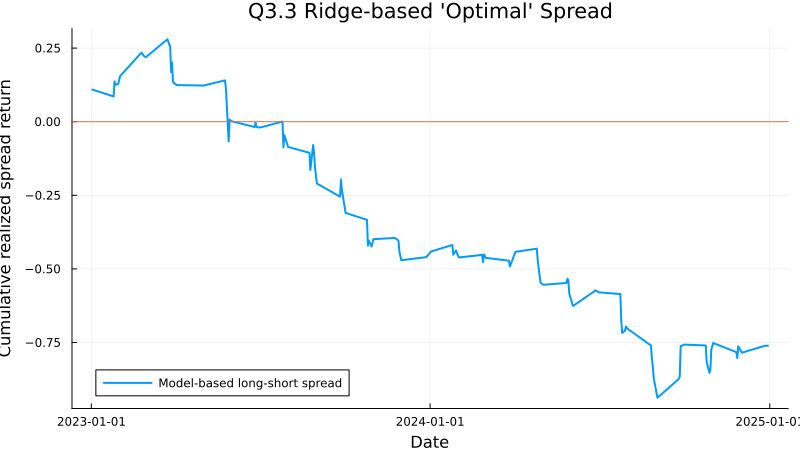

In [17]:
# Q3.3: Can Ridge be used to construct an optimal spread?
lambda = best_lambda
contracts = unique(df_q3.ID)
pred_list = DataFrame[]

for c in contracts
    tmp = filter(:ID => ==(c), df_q3)
    tmp = copy(tmp)

    train_c = filter(row -> 2017 <= year(row.Date) <= 2020, tmp)
    valid_c = filter(row -> 2023 <= year(row.Date) <= 2024, tmp)

    dropmissing!(train_c, vcat(predictors, :Target))
    dropmissing!(valid_c, vcat(predictors, :Target))

    if nrow(train_c) == 0 || nrow(valid_c) == 0
        continue
    end

    Xtr = Matrix(train_c[:, predictors])
    ytr = train_c.Target
    Xva = Matrix(valid_c[:, predictors])

    beta = ridge(Xtr, ytr, lambda)
    yhat = Xva * beta

    out = DataFrame(
        Date = valid_c.Date,
        ID = fill(c, nrow(valid_c)),
        Pred = yhat,
        Realized = valid_c.Target
    )

    push!(pred_list, out)
end

pred_df = vcat(pred_list...)

# For each day: long highest predicted return, short lowest predicted return
g = groupby(pred_df, :Date)

spread_df = combine(g) do x
    x = sort(x, :Pred)
    short_leg = x[1, :]
    long_leg  = x[end, :]

    DataFrame(
        Date = [x.Date[1]],
        LongID = [long_leg.ID],
        ShortID = [short_leg.ID],
        PredSpread = [long_leg.Pred - short_leg.Pred],
        RealizedSpread = [long_leg.Realized - short_leg.Realized]
    )
end

spread_df.CumSpread = cumsum(spread_df.RealizedSpread)

println("Average realized spread return: ", mean(spread_df.RealizedSpread))
println("Total realized spread return: ", sum(spread_df.RealizedSpread))
println("Number of spread trades: ", nrow(spread_df))

plot(
    spread_df.Date,
    spread_df.CumSpread,
    label = "Model-based long-short spread",
    xlabel = "Date",
    ylabel = "Cumulative realized spread return",
    title = "Q3.3 Ridge-based 'Optimal' Spread",
    linewidth = 2,
    size = (800, 450)
)

hline!([0], label = "", linewidth = 1)

---
### Q4.1-Q4.4 — Model, Inputs & Assumptions 

**Model: Black-76 (Black's model for futures options)**

**Formula for a European call:**

$$C = e^{-rT} \left[ F \cdot N(d_1) - K \cdot N(d_2) \right]$$

$$d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

| Input | Symbol | Value / Source |
|-------|--------|---------------|
| Futures price | F | Close price of EEXFM2 on Feb 27 (from data.csv) |
| Strike | K | 70 EUR/MWh |
| Risk-free rate | r | 0% (standard for short-dated power futures options) |
| Volatility | σ | Estimated from historical returns of the underlying (rolling 45-day std × √252) |
| Time to expiry | T | (March 31 − Feb 27) / 365 in years |

**Key assumptions:**
1. The futures price follows a log-normal process (standard Black-76 assumption).
2. Constant volatility over the life of the option - we use historical volatility as a proxy for implied volatility.
3. No transaction costs or bid-ask spread.
4. The option expires worthless or pays max(F_T - K, 0) at expiry.
5. r = 0 is justified because the option life is very short (~32 days) and EUR short-term rates are near zero.

---

### Realised PNL: Feb 27 → Mar 3

We reprice the option on **Monday, March 3** using the close futures price and compute:

- **Unhedged PNL:** Change in option value × ContractSize (EUR). As option sellers, we profit if the option value falls (futures price falls or time decays).
- **Delta-hedged PNL:** Unhedged PNL + PNL from the delta hedge in the futures. Each day, we rebalance the futures position to match the updated delta.


In [18]:
function black76_call(F, K, r, σ, T)
    if T <= 0
        return max(F - K, 0.0)
    end
    d1 = (log(F / K) + 0.5 * σ^2 * T) / (σ * sqrt(T))
    d2 = d1 - σ * sqrt(T)
    return exp(-r * T) * (F * cdf(Normal(), d1) - K * cdf(Normal(), d2))
end

function black76_delta(F, K, r, σ, T)
    if T <= 0
        return F > K ? 1.0 : 0.0
    end
    d1 = (log(F / K) + 0.5 * σ^2 * T) / (σ * sqrt(T))
    return exp(-r * T) * cdf(Normal(), d1)
end

function black76_gamma(F, K, r, σ, T)
    if T <= 0
        return 0.0
    end
    d1 = (log(F / K) + 0.5 * σ^2 * T) / (σ * sqrt(T))
    return exp(-r * T) * pdf(Normal(), d1) / (F * σ * sqrt(T))
end


black76_gamma (generic function with 1 method)

In [19]:
# -----------------------------
# User settings
# -----------------------------
symbol_key   = "EEX DEB APR-2026"
trade_date   = Date(2026, 2, 27)
start_date   = Date(2026, 3, 3)
expiry       = Date(2026, 3, 31)

K            = 70.0
r            = 0.0
days_in_year = 365.0

# Volatility choice:
# use_estimated_sigma = true  -> estimate from history
# use_estimated_sigma = false -> use manual_sigma below
use_estimated_sigma = true
manual_sigma        = 0.35

# -----------------------------
# Helper functions
# -----------------------------
time_to_expiry(d, expiry; days_in_year=365.0) =
    max((expiry - d) / Day(1) / days_in_year, 0.0)

function estimate_sigma(df, symbol_key, trade_date)
    hist = copy(filter(row -> row.SymbolKey == symbol_key &&
        row.Date <= trade_date, df))
    hist.ret = allowmissing(hist.ret)
    replace!(hist.ret, -99 => missing)
    return std(skipmissing(hist.ret)) * sqrt(252)
end

# -----------------------------
# Data selection
# -----------------------------
option = sort!(copy(filter(row -> row.SymbolKey == symbol_key &&
    start_date <= row.Date <= expiry, df)), :Date)

option_trade = copy(filter(row -> row.SymbolKey == symbol_key &&
    row.Date == trade_date, df))

if nrow(option_trade) == 0
    error("No observation found for trade date $(trade_date).")
end

# -----------------------------
# Volatility assumption
# -----------------------------
σ = use_estimated_sigma ? estimate_sigma(df, symbol_key, trade_date) : manual_sigma
println("Volatility used (σ): ", round(σ, digits=4))

# -----------------------------
# Time-to-expiry and option values
# -----------------------------
T_vec = time_to_expiry.(option.Date, expiry; days_in_year=days_in_year)

option.OptionPrice = black76_call.(option.Price, K, r, σ, T_vec)
option.Delta       = black76_delta.(option.Price, K, r, σ, T_vec)
option.Gamma       = black76_gamma.(option.Price, K, r, σ, T_vec)

# Force expiry values to payoff / terminal Greeks
option.OptionPrice[end] = max(option.Price[end] - K, 0.0)
option.Delta[end]       = option.Price[end] > K ? 1.0 : 0.0
option.Gamma[end]       = 0.0

# -----------------------------
# Key dates for display
# -----------------------------
F_trade = option_trade.Price[1]
F_start = option.Price[1]

T_trade = time_to_expiry(trade_date, expiry; days_in_year=days_in_year)
T_start = T_vec[1]

dates_display = [trade_date, start_date]
F_display     = [F_trade, F_start]
T_display     = [T_trade, T_start]

C_display = black76_call.(F_display, K, r, σ, T_display)
Δ_display = black76_delta.(F_display, K, r, σ, T_display)
Γ_display = black76_gamma.(F_display, K, r, σ, T_display)

# -----------------------------
# PNL calculations
# -----------------------------
Q = option.ContractSize[1]

PnL_unhedged = Q * (option.OptionPrice[1] - option.OptionPrice[end])

dF = [missing; diff(option.Price)]
hedge_pnl = [i == 1 ? missing : Q * option.Delta[i-1] * dF[i] for i in 1:nrow(option)]
PnL_hedged = PnL_unhedged + sum(skipmissing(hedge_pnl))

# -----------------------------
# Summary table
# -----------------------------
summary_q4 = DataFrame(
    Metric = ["FuturesPrice", "TimeToExpiry", "CallPrice", "Delta", "Gamma",
              "Unhedged PNL (EUR)", "Delta-hedged PNL (EUR)"],
    Feb27  = [round(F_display[1], digits=4), round(T_display[1], digits=6),
              round(C_display[1], digits=4), round(Δ_display[1], digits=6),
              round(Γ_display[1], digits=6), round(PnL_unhedged, digits=2), round(PnL_hedged, digits=2)],
    Mar03  = [round(F_display[2], digits=4), round(T_display[2], digits=6),
              round(C_display[2], digits=4), round(Δ_display[2], digits=6),
              round(Γ_display[2], digits=6), "", ""]
)

println("\nQ4 SUMMARY TABLE")
show(summary_q4, allrows=true, allcols=true)
println()

Volatility used (σ): 0.3615

Q4 SUMMARY TABLE
7×3 DataFrame
 Row │ Metric                  Feb27        Mar03    
     │ String                  Float64      Any      
─────┼───────────────────────────────────────────────
   1 │ FuturesPrice              73.67      100.6
   2 │ TimeToExpiry               0.087671  0.076712
   3 │ CallPrice                  5.2435    30.6003
   4 │ Delta                      0.702263  0.99988
   5 │ Gamma                      0.043941  4.7e-5
   6 │ Unhedged PNL (EUR)      5450.62
   7 │ Delta-hedged PNL (EUR)     0.87
